## 1. Import Necessary Library

In [184]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,auc,roc_curve,classification_report,confusion_matrix,roc_auc_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from pickle import dump,load
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,StackingClassifier,VotingClassifier
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

## 2. Data Collection

In [115]:
claim_data = pd.read_csv("claimants.csv")
claim_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## 3. Data Understanding

In [116]:
claim_data.shape

(1340, 7)

In [117]:
claim_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

## 4. Data Preparation

In [118]:
claim_data.dropna(inplace= True)

In [119]:
claim_data.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


In [120]:
X = claim_data.drop(["CASENUM","ATTORNEY"],axis = 1)

In [121]:
Y = claim_data["ATTORNEY"]

In [122]:
X.columns

Index(['CLMSEX', 'CLMINSUR', 'SEATBELT', 'CLMAGE', 'LOSS'], dtype='object')

## 5 . Model Building

In [192]:
from sklearn.model_selection import train_test_split,KFold,LeaveOneOut,cross_val_score

### 5.1 Train_test_Split

In [193]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size = 0.2,shuffle=True,random_state=10)


### 5.2 K Fold

In [206]:
kfold_mod = KFold(n_splits=5,shuffle=True,random_state= 12)
k_fold_cross_Val = cross_val_score(estimator=dt_model,X=X,y=Y,cv=kfold_mod)
print("K_Fold_Mean Val :",k_fold_cross_Val.mean().round(2))
print("K_Fold_std Val :",k_fold_cross_Val.std().round(2))

K_Fold_Mean Val : 0.72
K_Fold_std Val : 0.04


### 5.3 LOOCV(Leave One Out Cross Validation

In [208]:
LOOCV_Mod = LeaveOneOut()
looocv_cross_Val = cross_val_score(estimator=dt_model,X=X,y=Y,cv=LOOCV_Mod)
print("K_Fold_Mean Val :",looocv_cross_Val.mean().round(2))
print("K_Fold_std Val :",looocv_cross_Val.std().round(2))

K_Fold_Mean Val : 0.73
K_Fold_std Val : 0.44


In [209]:
## Note As STD Deviation is so high this Module validation is suggestable 

In [92]:
dt_model = DecisionTreeClassifier(criterion = "entropy",max_depth = 5) ## Decision Tree 

In [150]:
rf_Model = RandomForestClassifier(n_estimators=100,criterion='gini',max_depth=5)

In [168]:
ada_model = AdaBoostClassifier()

##  Grid Search  CV (Cross Validation)

to find the best Parameter for the Decision Tree

In [146]:
gd_Search = GridSearchCV(estimator= rf_Model,param_grid = {"max_depth": [5,7,8,9,10], "criterion": ["gini", "entropy"],"n_estimators":[50,60,70,75,90,100]})

In [147]:
gd_Search.fit(X_train,y_train)


,estimator,RandomForestClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [5, 7, ...], 'n_estimators': [50, 60, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [149]:
print(gd_Search.best_params_)
print(gd_Search.best_score_)

{'criterion': 'gini', 'max_depth': 5, 'n_estimators': 100}
0.7226168831168832


np.float64(0.7248831168831169)

### Plot Tree

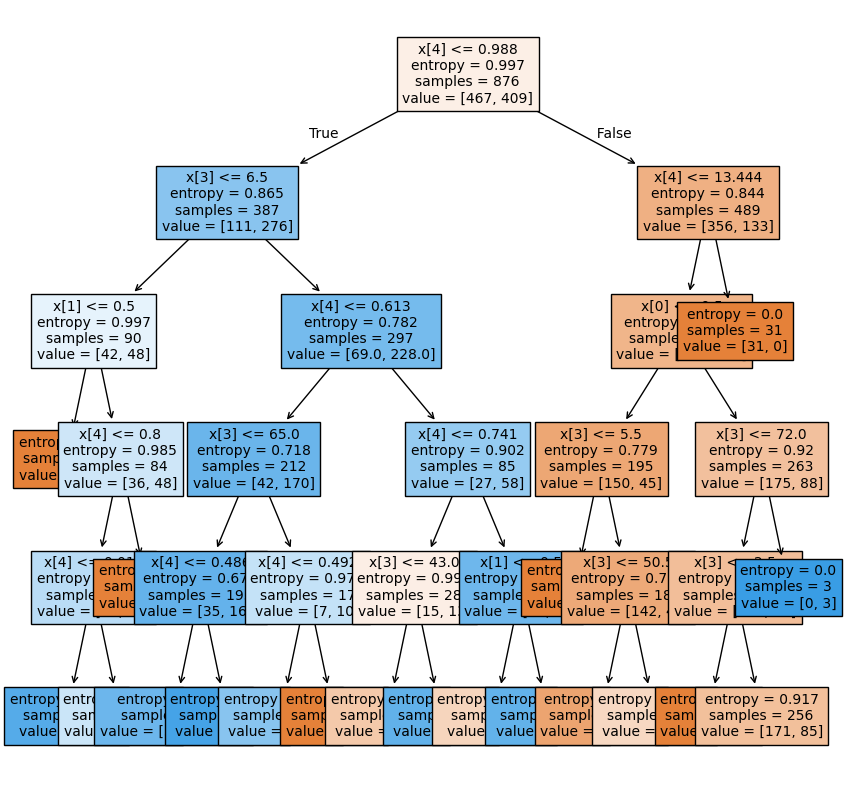

In [97]:
plt.figure(figsize = (10,10))
plot_tree(dt_model,filled = True,fontsize= 10)
plt.show()

## 6 Module Training

In [ ]:
## Train Module Test

In [151]:
dt_model.fit(X_train,y_train) ## Decision Tree

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [153]:
rf_Model.fit(X_train,y_train) ### Random Forest

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [169]:
ada_model.fit(X_train,y_train) ### Adaboast Forest

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [ ]:
### Decisipn Tree Clasification

## Problems in the Decision Tree

1. Over Fitting, Under Fitting, Generalised Model

Baised and Variance

    Baised - Always refer the Train Data
    Variance - Always Refer test Data

Metrix :

     **  low Baised(High Accuracy) vs high Variance(low Accuracy) --> Over Fitting
     **  high Baised(low Accuracy) vs low Variance(high Accuracy) --> under Fitting
     ** low Baised(High Accuracy) vs low Variance(high Accuracy) --> Generalised

#### Stacking Module

In [185]:
log_module = LogisticRegression()
Dection_Module = DecisionTreeClassifier(max_depth=5)
kn_module = KNeighborsClassifier()

In [188]:
Vote_Module = VotingClassifier(estimators = [("log_Mod",log_module),("decision_tree",Dection_Module),("Kneighbour",kn_module)])
Vote_Module.fit(X,Y)

,estimators,"[('log_Mod', ...), ('decision_tree', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [189]:
Y_Pred_Vot =  Vote_Module.predict(X)

In [191]:
accuracy_score(Y,Y_Pred_Vot)

0.7582116788321168

## 7. Module Testing

### Train Data Prediction

In [99]:
y_preditc_train = dt_model.predict(X_train) ## Decision Tree

In [154]:
y_preditc_train = rf_Model.predict(X_train) ## random Forest

In [170]:
y_preditc_train = ada_model.predict(X_train) ## adaboast

### Test Data Prdiction

In [100]:
y_predict_test = dt_model.predict(X_test) ## Deciosn Tree

In [155]:
y_predict_test = rf_Model.predict(X_test) ## Random Forest

In [171]:
y_predict_test = ada_model.predict(X_test) ## Adaboast

## 8. Module Evaluation

In [172]:
accuracy_score(y_train,y_preditc_train)

0.7214611872146118

In [173]:
confusion_matrix(y_train,y_preditc_train)

array([[356, 111],
       [133, 276]])

In [174]:
print(classification_report(y_train,y_preditc_train))

              precision    recall  f1-score   support

           0       0.73      0.76      0.74       467
           1       0.71      0.67      0.69       409

    accuracy                           0.72       876
   macro avg       0.72      0.72      0.72       876
weighted avg       0.72      0.72      0.72       876



#### ROC Curve (Reciver Operation CHaracteristic
#### AUC -- Area Under the Curve

In [175]:
fpr,tpr,threshold = roc_curve(y_train,ada_model.predict_proba(X_train)[:,1])

In [176]:
auc1 = roc_auc_score(y_train,y_preditc_train)
##roc_auc_score(y_train,dt_model.predict_proba(X_train)[:,1])
print(auc1)

0.7185646298749234


Text(0, 0.5, 'True Positive Rate')

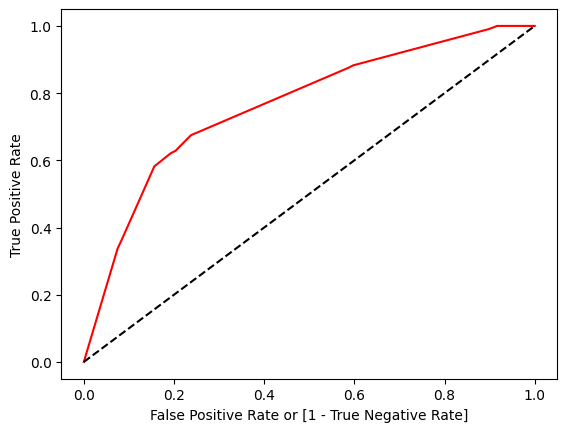

In [177]:
plt.plot(fpr,tpr, color = 'red',label='logit model ( area  = %0.2f)'%auc1)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

In [ ]:
#### Test Data Module Evaluation

In [178]:
accuracy_score(y_test,y_predict_test)

0.7454545454545455

### Confusion Metric

In [179]:
print(confusion_matrix(y_test,y_predict_test))

[[83 28]
 [28 81]]


### Clasification Report

In [180]:
print(classification_report(y_test,y_predict_test))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75       111
           1       0.74      0.74      0.74       109

    accuracy                           0.75       220
   macro avg       0.75      0.75      0.75       220
weighted avg       0.75      0.75      0.75       220



### Roc Curve(Receive Opetion Charatceristic)
### AuC Area Under the Curve

In [181]:
fprt,trpt,thresholdt = roc_curve(y_test,ada_model.predict_proba(X_test)[:,1]) ## Check the Estimotor Module

In [182]:
auct = roc_auc_score(y_test,y_predict_test)
print(auct)

0.7454335069013969


Text(0, 0.5, 'True Positive Rate')

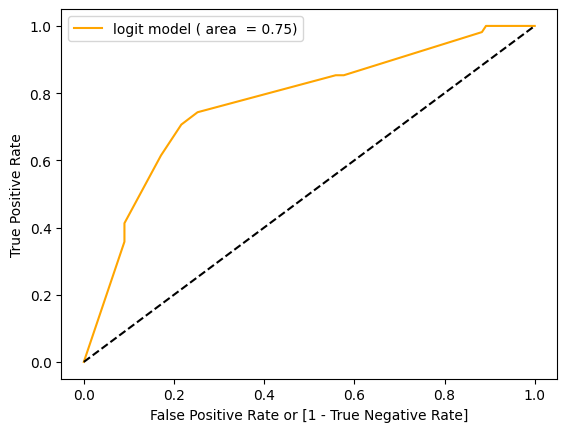

In [183]:
plt.plot(fprt,trpt,color = 'Orange',label = 'logit model ( area  = %0.2f)' %auct)
plt.plot([0,1],[0,1],'--k')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.legend()
plt.ylabel('True Positive Rate')

## 9. Module Deployment

In [22]:
dump(claim_module,open("claim_module.pkl",mode="wb"))

#### ======================================  END  ==================================================